Import dependencies

In [26]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

Import dataset

In [27]:
file_path = "assets/hes-admi-diag-2019-23-tab.xlsx"

# Specify required column names
cols = ["ICD code summary", "ICD code summary description", "Finished consultant episodes", "Male"]

# Note badly named column
bad_column_name = "Male \n(FCE)"

# Import all datasets dataframes
datasets = {
    "df2011": pd.read_excel(file_path, sheet_name="2011", usecols=cols),
    "df2012": pd.read_excel(file_path, sheet_name="2012", usecols=cols),
    "df2013": pd.read_excel(file_path, sheet_name="2013", usecols=cols),
    "df2014": pd.read_excel(file_path, sheet_name="2014", usecols=cols),
    "df2015": pd.read_excel(file_path, sheet_name="2015", usecols=cols),
    "df2016": pd.read_excel(file_path, sheet_name="2016", usecols=cols),
    "df2017": pd.read_excel(file_path, sheet_name="2017", usecols=cols),
    "df2018": pd.read_excel(file_path, sheet_name="2018", usecols=cols),
    "df2019": pd.read_excel(file_path, sheet_name="2019", usecols=cols),
    "df2020": pd.read_excel(file_path, sheet_name="2020", usecols=cols),
    "df2021": pd.read_excel(file_path, sheet_name="2021", usecols=cols),
    "df2022": pd.read_excel(file_path, sheet_name="2022", usecols=cols),
    "df2023": pd.read_excel(
        file_path,
        sheet_name="2023",
        usecols=[
            "ICD code summary",
            "ICD code summary description",
            "Finished consultant episodes",
            bad_column_name,
        ],
    ),
}

Preview dataset sample

In [28]:
datasets["df2020"]

,Finished consultant episodes,Male,ICD code summary description,ICD code summary
0,129041,53966,Certain infectious and parasitic diseases,A00–B99
1,4290,2923,Certain infectious and parasitic diseases,A00–B99
2,244,170,Certain infectious and parasitic diseases,A00–B99
3,215588,116668,Certain infectious and parasitic diseases,A00–B99
4,1791,977,Certain infectious and parasitic diseases,A00–B99
...,...,...,...,...
210,487868,190055,Factors influencing health status and contact ...,Z00–Z99
211,81177,45729,Factors influencing health status and contact ...,Z00–Z99
212,904,386,Factors influencing health status and contact ...,Z00–Z99
213,15947,6918,Factors influencing health status and contact ...,Z00–Z99


Rename oddly named column

In [29]:
datasets["df2023"].rename(columns={bad_column_name: "Male"}, inplace=True)

Add a `Year` column to each dataframe to maintain individuality

In [30]:
for key in datasets.keys():
    datasets[key]["Year"] = key[-4:]

Merge all dataframes into a single dataframe

In [31]:
df = pd.concat(datasets.values(), ignore_index=True)
df

,Finished consultant episodes,Male,ICD code summary description,ICD code summary,Year
0,66147,30525,Certain infectious and parasitic diseases,A00–B99,2011
1,7590,4540,Certain infectious and parasitic diseases,A00–B99,2011
2,59046,29542,Certain infectious and parasitic diseases,A00–B99,2011
3,2824,1349,Certain infectious and parasitic diseases,A00–B99,2011
4,393,245,Certain infectious and parasitic diseases,A00–B99,2011
...,...,...,...,...,...
2258,509719,184215,Factors influencing health status and contact ...,Z00–Z99,2023
2259,111774,59131,Factors influencing health status and contact ...,Z00–Z99,2023
2260,1269,529,Factors influencing health status and contact ...,Z00–Z99,2023
2261,21795,9135,Factors influencing health status and contact ...,Z00–Z99,2023


Aggregate `Male` and `Finished consultant episodes` into summation based off the `Year` and `ICD code summary`

In [32]:
# Group by Year, ICD code summary and sum up the Male column and Finished consultant episodes column
# However include `ICD code summary description` to the output
df[["Male", "Finished consultant episodes"]] = df[["Male", "Finished consultant episodes"]].apply(pd.to_numeric, errors="coerce")
df_grouped = df.groupby(
    ["Year", "ICD code summary", "ICD code summary description"], as_index=False
).agg({"Male": "sum", "Finished consultant episodes": "sum"})

df_grouped

,Year,ICD code summary,ICD code summary description,Male,Finished consultant episodes
0,2011,A00–B99,Certain infectious and parasitic diseases,137764.0,261356
1,2011,C00–D48,Neoplasms,894569.0,1820659
2,2011,D50–D89,Diseases of the blood and blood–forming organs...,140008.0,301190
3,2011,E00–E90,"Endocrine, nutritional and metabolic diseases",146478.0,295428
4,2011,F00–F99,Mental and behavioural disorders,130730.0,241853
...,...,...,...,...,...
262,2023,Q00–Q99,"Congenital malformations, deformations and chr...",61048.0,109246
263,2023,R00–R99,"Symptoms, signs and abnormal clinical and labo...",1029004.0,2312508
264,2023,S00–T98,"Injury, poisoning and certain other consequenc...",627959.0,1278212
265,2023,U00–U85,Codes for special purposes,52819.0,105758


Compute the `Percentage gender difference` based off `Male` and include it as a feature to the dataframe

In [33]:
df_grouped["Percentage gender difference"] = (
    ((2 * df_grouped["Male"]) - df_grouped["Finished consultant episodes"])
    / df_grouped["Finished consultant episodes"]
) * 100

df_grouped

,Year,ICD code summary,ICD code summary description,Male,Finished consultant episodes,Percentage gender difference
0,2011,A00–B99,Certain infectious and parasitic diseases,137764.0,261356,5.422489
1,2011,C00–D48,Neoplasms,894569.0,1820659,-1.731296
2,2011,D50–D89,Diseases of the blood and blood–forming organs...,140008.0,301190,-7.030114
3,2011,E00–E90,"Endocrine, nutritional and metabolic diseases",146478.0,295428,-0.836752
4,2011,F00–F99,Mental and behavioural disorders,130730.0,241853,8.106991
...,...,...,...,...,...,...
262,2023,Q00–Q99,"Congenital malformations, deformations and chr...",61048.0,109246,11.762444
263,2023,R00–R99,"Symptoms, signs and abnormal clinical and labo...",1029004.0,2312508,-11.005367
264,2023,S00–T98,"Injury, poisoning and certain other consequenc...",627959.0,1278212,-1.744155
265,2023,U00–U85,Codes for special purposes,52819.0,105758,-0.113467


Drop the `Male` and `Finished consultant episodes` columns as they are no longer needed for visualisation

In [34]:
df_grouped.drop(["Male", "Finished consultant episodes"], axis=1, inplace=True)

Merge the `ICD code summary` and `ICD code summary description` columns together to form a new column `ICD code chapter`

In [35]:
df_grouped["ICD code chapter"] = (
    df_grouped["ICD code summary"] + " - " + df_grouped["ICD code summary description"]
)

Drop redundant features

In [36]:
df_grouped.drop(
    ["ICD code summary", "ICD code summary description"], axis=1, inplace=True
)

Generate a heatmap with `Year` on x axis, `ICD code summary description` on y axis and `Percentage gender difference` as the colour

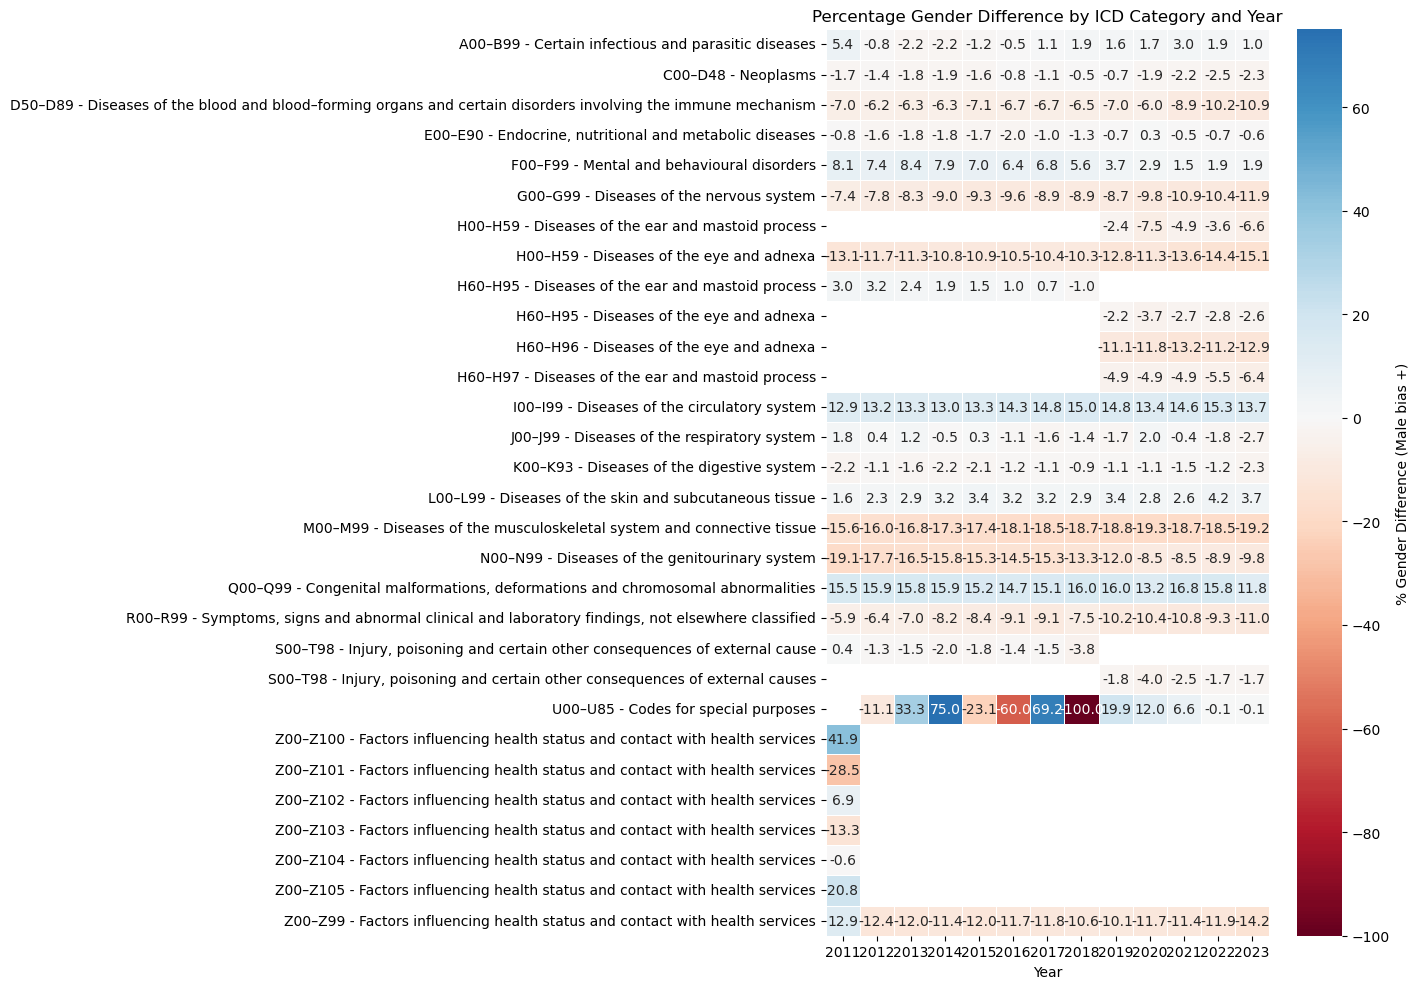

In [37]:
pivot = df_grouped.pivot_table(
    index="ICD code chapter",
    columns="Year",
    values="Percentage gender difference",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(14, 10))
sb.heatmap(
    pivot,
    cmap="RdBu",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "% Gender Difference (Male bias +)"},
)
ax.set_title("Percentage Gender Difference by ICD Category and Year")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()